<a href="https://colab.research.google.com/github/Naveen-gale/deep_learning/blob/main/rnn_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import joblib

In [7]:
df = pd.read_csv('data.csv')

In [8]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [9]:
df.shape

(5842, 2)

In [10]:
df.duplicated().sum()

np.int64(6)

In [11]:
df.isnull().sum()

,0
Sentence,0
Sentiment,0


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_586/833318319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


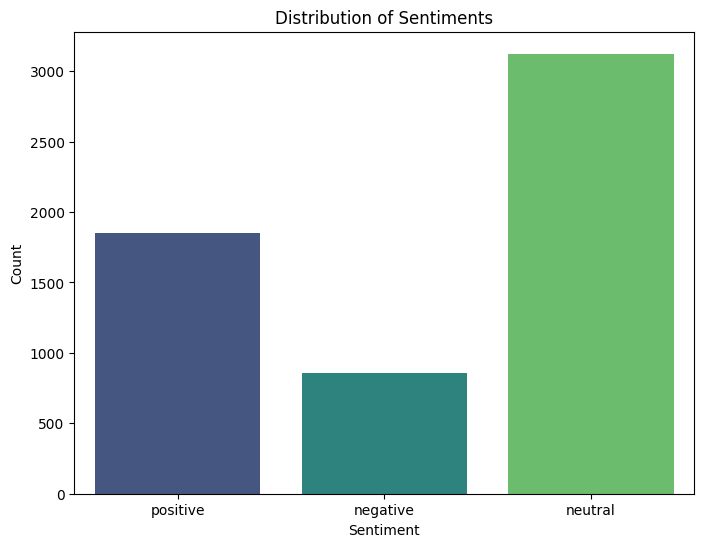

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [15]:
encode = LabelEncoder()
df['Sentiment'] = encode.fit_transform(df['Sentiment'])

In [16]:
encoder_filename = joblib.dump(encode, 'label_encoder.pkl')

In [17]:
X = df["Sentence"]

y = df["Sentiment"]

In [18]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)



In [20]:
tokenizer_filename = joblib.dump(tokenizer, 'tokenizer.pkl')

In [21]:
X_train_seq = X_train
X_test_seq = X_test

In [22]:
max_len = 50

In [25]:
X_train_seq_tokenized = tokenizer.texts_to_sequences(X_train)
X_test_seq_tokenized = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq_tokenized,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq_tokenized,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

In [26]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

10292


In [27]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    )
)

model.add(
    LSTM(128)
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        3,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
hestroy = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5204 - loss: 0.9960 - val_accuracy: 0.5702 - val_loss: 0.9689
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5268 - loss: 0.9944 - val_accuracy: 0.5702 - val_loss: 0.9555
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5270 - loss: 0.9908 - val_accuracy: 0.5685 - val_loss: 0.9606
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5394 - loss: 0.9748 - val_accuracy: 0.6113 - val_loss: 0.9161
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5859 - loss: 0.9413 - val_accuracy: 0.6087 - val_loss: 0.9105
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5921 - loss: 0.9281 - val_accuracy: 0.6173 - val_loss: 0.9130
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5988 - loss: 0.9229 - val_accuracy: 0.6190 - val_loss: 0.9173
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5988 - loss: 0.9241 - val_accuracy: 

In [31]:
evalute = model.evaluate(X_test_pad, y_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5976 - loss: 0.9105


In [33]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

import joblib

from tensorflow.keras.models import load_model

tokenizer = joblib.load("tokenizer.pkl")

encoder = joblib.load("label_encoder.pkl")

model = load_model("financial_sentiment.keras")

max_length = 50


def predict_sentiment(text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post"
    )

    prediction = model.predict(padded)

    index = np.argmax(prediction)

    label = encoder.inverse_transform([index])[0]

    confidence = prediction[0][index]

    return label, confidence

In [34]:
predict_sentiment(
    "Apple shares jump after strong quarterly earnings."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


('positive', np.float32(0.516509))

In [35]:
predict_sentiment(
    "Tesla reports disappointing production numbers."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


('positive', np.float32(0.5165089))

In [36]:
predict_sentiment(
    "Bitcoin trades in a narrow range."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


('neutral', np.float32(0.93697953))

In [1]:
history_dict = hestroy.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_values, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'hestroy' is not defined